# Notebook 3 — Feature Engineering
**Project:** Stock Price Movement Prediction Using Financial News Sentiment Analysis and Machine Learning  
**Student:** Venkata Kiran Kumar Mullapudi (16200362)  
**Ethics Approval:** P193120  

This notebook:
1. Loads price data and daily sentiment from NB1 + NB2
2. Merges both datasets on (date, ticker)
3. Calculates 9 technical indicators from price data
4. Handles missing sentiment days (forward-fill then zero-fill)
5. Builds 4 ablation feature matrices
6. Applies time-ordered 70/15/15 train/val/test split
7. Scales features using StandardScaler (fit on train only)
8. Saves all outputs for NB4 and NB5

> **CPU is fine — no GPU needed for this notebook**

## Cell 1 — Install dependencies

In [1]:
!pip install scikit-learn --upgrade --quiet
!pip install yfinance --quiet
print("Done — now restart kernel: Runtime → Restart session → then Run All")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 106.7 MB/s eta 0:00:00
Done — now restart kernel: Runtime → Restart session → then Run All


## Cell 2 — Imports

In [2]:
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pickle

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TICKERS    = ['AAPL','MSFT','AMZN','GOOGL','META','TSLA','NVDA','JPM','NFLX','^GSPC']
START_DATE = '2019-01-01'
END_DATE   = '2023-12-31'
LOOKBACK   = 20   # days for LSTM sequences (used in NB5)
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# test = remaining 0.15

print('All imports successful.')

All imports successful.


## Cell 3 — Load price data (NB1 output or yfinance fallback)

In [3]:
def find_file(filename):
    patterns = [
        f'/kaggle/working/outputs/{filename}',
        f'/kaggle/input/**/{filename}',
    ]
    for p in patterns:
        matches = glob.glob(p, recursive=True)
        if matches:
            return matches[0]
    return None

# ── Load price data ──────────────────────────────────────────────────────────
price_path = find_file('price_data_clean.csv')

if price_path:
    price_df = pd.read_csv(price_path)
    # Handle multi-level header artifact
    if str(price_df.iloc[0,0]) == 'Price':
        price_df = pd.read_csv(price_path, skiprows=1)
    date_col = [c for c in price_df.columns if 'date' in c.lower()]
    if date_col:
        price_df = price_df.rename(columns={date_col[0]: 'Date'})
    tick_col = [c for c in price_df.columns if 'ticker' in c.lower()]
    if tick_col:
        price_df = price_df.rename(columns={tick_col[0]: 'Ticker'})
    price_df['Date'] = pd.to_datetime(price_df['Date'], errors='coerce')
    price_df = price_df.dropna(subset=['Date'])
    print(f'✓ Price data loaded from file: {price_df.shape}')
else:
    print('Downloading price data via yfinance...')
    frames = []
    for ticker in TICKERS:
        df = yf.download(ticker, start=START_DATE, end=END_DATE,
                         auto_adjust=True, progress=False)
        if df.empty: continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.reset_index()
        df['Ticker'] = ticker
        df['Next_Close'] = df['Close'].shift(-1)
        df['Label']      = (df['Next_Close'] > df['Close']).astype(int)
        df['Daily_Return'] = df['Close'].pct_change() * 100
        frames.append(df)
    price_df = pd.concat(frames, ignore_index=True)
    price_df['Date'] = pd.to_datetime(price_df['Date'])
    print(f'✓ Price data downloaded: {price_df.shape}')

# ── Load sentiment data ──────────────────────────────────────────────────────
sent_path = find_file('daily_sentiment.csv')
if sent_path:
    sent_df = pd.read_csv(sent_path, parse_dates=['date'])
    sent_df['date'] = pd.to_datetime(sent_df['date']).dt.normalize()
    print(f'✓ Sentiment data loaded: {sent_df.shape}')
else:
    raise FileNotFoundError('daily_sentiment.csv not found — link NB2 output via + Add Data')

print(f'\nPrice columns  : {list(price_df.columns)}')
print(f'Sentiment cols : {list(sent_df.columns)}')

✓ Price data loaded from file: (12580, 10)
✓ Sentiment data loaded: (4475, 17)

Price columns  : ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Next_Close', 'Label', 'Daily_Return']
Sentiment cols : ['date', 'ticker', 'headline_count', 'finbert_score', 'finbert_pos_mean', 'finbert_neg_mean', 'finbert_neu_mean', 'vader_compound', 'vader_pos_mean', 'vader_neg_mean', 'vader_neu_mean', 'pos_count', 'neg_count', 'finbert_pos_ratio', 'finbert_neg_ratio', 'finbert_momentum', 'vader_momentum']


## Cell 4 — Calculate technical indicators

In [4]:
def compute_technical_indicators(df):
    """
    Compute 9 technical indicators per ticker.
    Input df must have: Date, Close, High, Low, Open, Volume columns.
    Returns df with added indicator columns.
    """
    df = df.copy().sort_values('Date')
    c = df['Close']

    # 1. Simple Moving Averages
    df['SMA_5']  = c.rolling(5,  min_periods=1).mean()
    df['SMA_20'] = c.rolling(20, min_periods=1).mean()
    df['SMA_50'] = c.rolling(50, min_periods=1).mean()

    # 2. RSI (14-day)
    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14, min_periods=1).mean()
    loss  = (-delta.clip(upper=0)).rolling(14, min_periods=1).mean()
    rs    = gain / (loss + 1e-9)
    df['RSI_14'] = 100 - (100 / (1 + rs))

    # 3. MACD and Signal line
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    df['MACD']        = ema12 - ema26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

    # 4. Bollinger Bands (20-day)
    bb_mean = c.rolling(20, min_periods=1).mean()
    bb_std  = c.rolling(20, min_periods=1).std()
    df['BB_Upper'] = bb_mean + 2 * bb_std
    df['BB_Lower'] = bb_mean - 2 * bb_std
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / (bb_mean + 1e-9)
    df['BB_Pct']   = (c - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'] + 1e-9)

    # 5. Rolling volatility
    ret = c.pct_change()
    df['Volatility_5']  = ret.rolling(5,  min_periods=1).std() * 100
    df['Volatility_20'] = ret.rolling(20, min_periods=1).std() * 100

    # 6. Price ratios (normalised)
    df['Price_SMA20_Ratio'] = c / (df['SMA_20'] + 1e-9)
    df['Price_SMA50_Ratio'] = c / (df['SMA_50'] + 1e-9)

    # 7. Volume change
    df['Volume_Change'] = df['Volume'].pct_change().fillna(0)

    return df

print('Computing technical indicators for all tickers...')
tech_frames = []
for ticker in TICKERS:
    sub = price_df[price_df['Ticker'] == ticker].copy()
    if len(sub) == 0:
        print(f'  {ticker} — no data')
        continue
    sub = compute_technical_indicators(sub)
    tech_frames.append(sub)
    print(f'  {ticker:6s} — {len(sub)} rows, indicators computed')

price_tech = pd.concat(tech_frames, ignore_index=True)
print(f'\nCombined price + indicators shape: {price_tech.shape}')

# List all technical feature columns
TECH_FEATURES = [
    'SMA_5','SMA_20','SMA_50',
    'RSI_14',
    'MACD','MACD_Signal','MACD_Hist',
    'BB_Width','BB_Pct',
    'Volatility_5','Volatility_20',
    'Price_SMA20_Ratio','Price_SMA50_Ratio',
    'Volume_Change',
    'Daily_Return'
]
print(f'\nTechnical features ({len(TECH_FEATURES)}): {TECH_FEATURES}')

Computing technical indicators for all tickers...
  AAPL   — 1258 rows, indicators computed
  MSFT   — 1258 rows, indicators computed
  AMZN   — 1258 rows, indicators computed
  GOOGL  — 1258 rows, indicators computed
  META   — 1258 rows, indicators computed
  TSLA   — 1258 rows, indicators computed
  NVDA   — 1258 rows, indicators computed
  JPM    — 1258 rows, indicators computed
  NFLX   — 1258 rows, indicators computed
  ^GSPC  — 1258 rows, indicators computed

Combined price + indicators shape: (12580, 26)

Technical features (15): ['SMA_5', 'SMA_20', 'SMA_50', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Width', 'BB_Pct', 'Volatility_5', 'Volatility_20', 'Price_SMA20_Ratio', 'Price_SMA50_Ratio', 'Volume_Change', 'Daily_Return']


## Cell 5 — Merge price + sentiment on (Date, Ticker)

In [5]:
# Normalise date columns for merging
price_tech['Date'] = pd.to_datetime(price_tech['Date']).dt.normalize()
sent_df['date']    = pd.to_datetime(sent_df['date']).dt.normalize()
sent_df['Ticker']  = sent_df['ticker'].str.upper()

# Sentiment feature columns to use
SENT_FEATURES_FINBERT = [
    'finbert_score', 'finbert_pos_mean', 'finbert_neg_mean', 'finbert_neu_mean',
    'finbert_pos_ratio', 'finbert_neg_ratio', 'finbert_momentum',
    'headline_count'
]
SENT_FEATURES_VADER = [
    'vader_compound', 'vader_pos_mean', 'vader_neg_mean', 'vader_neu_mean',
    'vader_momentum'
]
ALL_SENT_FEATURES = SENT_FEATURES_FINBERT + SENT_FEATURES_VADER

# Select only needed sentiment columns for merge
sent_merge = sent_df[['date','Ticker'] + ALL_SENT_FEATURES].copy()

# Merge
merged = price_tech.merge(
    sent_merge,
    left_on=['Date','Ticker'],
    right_on=['date','Ticker'],
    how='left'
).drop(columns=['date'], errors='ignore')

print(f'Merged dataset shape (before fill): {merged.shape}')
missing_sent = merged[ALL_SENT_FEATURES[0]].isna().sum()
print(f'Rows with no sentiment data       : {missing_sent:,} ({100*missing_sent/len(merged):.1f}%)')

# Forward-fill sentiment per ticker (use last known sentiment value)
merged = merged.sort_values(['Ticker','Date'])
for col in ALL_SENT_FEATURES:
    merged[col] = merged.groupby('Ticker')[col].transform(
        lambda x: x.fillna(method='ffill')
    )

# Zero-fill any remaining NaN (no prior sentiment available)
for col in ALL_SENT_FEATURES:
    merged[col] = merged[col].fillna(0)

missing_after = merged[ALL_SENT_FEATURES[0]].isna().sum()
print(f'Rows with no sentiment after fill  : {missing_after}')
print(f'Final merged shape                 : {merged.shape}')

Merged dataset shape (before fill): (12580, 39)
Rows with no sentiment data       : 8,849 (70.3%)
Rows with no sentiment after fill  : 0
Final merged shape                 : (12580, 39)


## Cell 6 — Drop rows with NaN in technical features, report final dataset

In [6]:
# Drop rows where label is NaN (last row per ticker)
merged = merged.dropna(subset=['Label'])
merged['Label'] = merged['Label'].astype(int)

# Drop rows where ANY technical feature is NaN
before = len(merged)
merged = merged.dropna(subset=TECH_FEATURES)
after  = len(merged)
print(f'Rows dropped due to NaN in tech features: {before - after}')
print(f'Final clean dataset shape: {merged.shape}')

print('\n=== Dataset Summary ===')
print(f'Tickers  : {sorted(merged["Ticker"].unique())}')
print(f'Date range: {merged["Date"].min().date()} to {merged["Date"].max().date()}')
print(f'Total rows: {len(merged):,}')
print(f'Labels   : Up={merged["Label"].sum():,} ({100*merged["Label"].mean():.1f}%)  Down={(~merged["Label"].astype(bool)).sum():,} ({100*(1-merged["Label"].mean()):.1f}%)')

print('\nRows per ticker:')
print(merged.groupby('Ticker').size().to_frame('rows').to_string())

Rows dropped due to NaN in tech features: 20
Final clean dataset shape: (12560, 39)

=== Dataset Summary ===
Tickers  : ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'META', 'MSFT', 'NFLX', 'NVDA', 'TSLA', '^GSPC']
Date range: 2019-01-04 to 2023-12-29
Total rows: 12,560
Labels   : Up=6,652 (53.0%)  Down=5,908 (47.0%)

Rows per ticker:
        rows
Ticker      
AAPL    1256
AMZN    1256
GOOGL   1256
JPM     1256
META    1256
MSFT    1256
NFLX    1256
NVDA    1256
TSLA    1256
^GSPC   1256


## Cell 7 — Build 4 feature matrices for ablation study

In [7]:
# Define 4 feature configurations for ablation
FEATURE_CONFIGS = {
    'price_only'      : TECH_FEATURES,
    'price_vader'     : TECH_FEATURES + SENT_FEATURES_VADER,
    'price_finbert'   : TECH_FEATURES + SENT_FEATURES_FINBERT,
    'price_both'      : TECH_FEATURES + ALL_SENT_FEATURES,
}

print('=== Feature Configuration Summary ===')
for name, cols in FEATURE_CONFIGS.items():
    print(f'  {name:20s} : {len(cols):2d} features')

print(f'\nTotal unique features: {len(set(TECH_FEATURES + ALL_SENT_FEATURES))}')
print(f'\nTechnical features ({len(TECH_FEATURES)}):')
for f in TECH_FEATURES:
    print(f'  - {f}')
print(f'\nFinBERT sentiment features ({len(SENT_FEATURES_FINBERT)}):')
for f in SENT_FEATURES_FINBERT:
    print(f'  - {f}')
print(f'\nVADER sentiment features ({len(SENT_FEATURES_VADER)}):')
for f in SENT_FEATURES_VADER:
    print(f'  - {f}')

=== Feature Configuration Summary ===
  price_only           : 15 features
  price_vader          : 20 features
  price_finbert        : 23 features
  price_both           : 28 features

Total unique features: 28

Technical features (15):
  - SMA_5
  - SMA_20
  - SMA_50
  - RSI_14
  - MACD
  - MACD_Signal
  - MACD_Hist
  - BB_Width
  - BB_Pct
  - Volatility_5
  - Volatility_20
  - Price_SMA20_Ratio
  - Price_SMA50_Ratio
  - Volume_Change
  - Daily_Return

FinBERT sentiment features (8):
  - finbert_score
  - finbert_pos_mean
  - finbert_neg_mean
  - finbert_neu_mean
  - finbert_pos_ratio
  - finbert_neg_ratio
  - finbert_momentum
  - headline_count

VADER sentiment features (5):
  - vader_compound
  - vader_pos_mean
  - vader_neg_mean
  - vader_neu_mean
  - vader_momentum


## Cell 8 — Time-ordered train / val / test split

In [8]:
# REPLACEMENT CELL — paste this over the existing Cell 17 (the one with NameError)
import numpy as np
from sklearn.preprocessing import StandardScaler

# Re-define all variables needed (safe to re-run)
TECH_FEATURES = [
    'SMA_5','SMA_20','SMA_50','RSI_14',
    'MACD','MACD_Signal','MACD_Hist',
    'BB_Width','BB_Pct',
    'Volatility_5','Volatility_20',
    'Price_SMA20_Ratio','Price_SMA50_Ratio',
    'Volume_Change','Daily_Return'
]
SENT_FINBERT = ['finbert_score','finbert_pos_mean','finbert_neg_mean',
                'finbert_neu_mean','finbert_pos_ratio','finbert_neg_ratio',
                'finbert_momentum','headline_count']
SENT_VADER   = ['vader_compound','vader_pos_mean','vader_neg_mean',
                'vader_neu_mean','vader_momentum']
ALL_SENT     = SENT_FINBERT + SENT_VADER

FEATURE_CONFIGS = {
    'price_only'    : TECH_FEATURES,
    'price_vader'   : TECH_FEATURES + SENT_VADER,
    'price_finbert' : TECH_FEATURES + SENT_FINBERT,
    'price_both'    : TECH_FEATURES + ALL_SENT,
}

# ── Step 1: Time split ────────────────────────────────────────────────────────
def time_split(df, train_frac=0.70, val_frac=0.15):
    tr, vl, te = [], [], []
    for ticker in df['Ticker'].unique():
        sub = df[df['Ticker']==ticker].sort_values('Date').reset_index(drop=True)
        n  = len(sub)
        t1 = int(n * train_frac)
        t2 = int(n * (train_frac + val_frac))
        tr.append(sub.iloc[:t1])
        vl.append(sub.iloc[t1:t2])
        te.append(sub.iloc[t2:])
    return (pd.concat(tr, ignore_index=True),
            pd.concat(vl, ignore_index=True),
            pd.concat(te, ignore_index=True))

train_df, val_df, test_df = time_split(merged)
total = len(merged)

print('=== Train / Validation / Test Split ===')
for name, df_ in [('Train',train_df),('Val',val_df),('Test',test_df)]:
    print(f'  {name:5s}: {len(df_):6,} rows ({100*len(df_)/total:.0f}%)  '
          f'{df_["Date"].min().date()} → {df_["Date"].max().date()}  '
          f'Up: {100*df_["Label"].mean():.1f}%')

print('\nSplit per ticker:')
rows = []
for t in ['AAPL','MSFT','AMZN','GOOGL','META','TSLA','NVDA','JPM','NFLX','^GSPC']:
    tr = len(train_df[train_df['Ticker']==t])
    vl = len(val_df[val_df['Ticker']==t])
    te = len(test_df[test_df['Ticker']==t])
    rows.append({'Ticker':t,'Train':tr,'Val':vl,'Test':te,'Total':tr+vl+te})
import pandas as pd
split_summary = pd.DataFrame(rows)
print(split_summary.to_string(index=False))

# ── Step 2: Clean inf/NaN ─────────────────────────────────────────────────────
all_model_cols = list(set(TECH_FEATURES + ALL_SENT))
for df_ in [train_df, val_df, test_df]:
    df_.sort_values(['Ticker','Date'], inplace=True)
    for col in all_model_cols:
        if col in df_.columns:
            df_[col] = df_[col].replace([np.inf, -np.inf], np.nan)
            df_[col] = df_.groupby('Ticker')[col].ffill().bfill().fillna(0)
            df_[col] = df_[col].clip(-1e6, 1e6)

for name, df_ in [('train',train_df),('val',val_df),('test',test_df)]:
    bad = sum(df_[col].isin([np.inf,-np.inf]).sum() + df_[col].isna().sum()
              for col in all_model_cols if col in df_.columns)
    print(f'{name:5s} — remaining inf/nan: {bad}')

# ── Step 3: Scale + build datasets ───────────────────────────────────────────
datasets = {}
for name, feature_cols in FEATURE_CONFIGS.items():
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train_df[feature_cols].values)
    X_val   = scaler.transform(val_df[feature_cols].values)
    X_test  = scaler.transform(test_df[feature_cols].values)
    datasets[name] = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': train_df['Label'].values,
        'y_val'  : val_df['Label'].values,
        'y_test' : test_df['Label'].values,
        'scaler' : scaler, 'feature_cols': feature_cols, 'n_features': len(feature_cols)
    }
    print(f'  {name:20s}  X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}')

print('\nAll 4 feature matrices built and scaled successfully.')

=== Train / Validation / Test Split ===
  Train:  8,790 rows (70%)  2019-01-04 → 2022-06-30  Up: 53.2%
  Val  :  1,880 rows (15%)  2022-07-01 → 2023-03-30  Up: 50.4%
  Test :  1,890 rows (15%)  2023-03-31 → 2023-12-29  Up: 54.2%

Split per ticker:
Ticker  Train  Val  Test  Total
  AAPL    879  188   189   1256
  MSFT    879  188   189   1256
  AMZN    879  188   189   1256
 GOOGL    879  188   189   1256
  META    879  188   189   1256
  TSLA    879  188   189   1256
  NVDA    879  188   189   1256
   JPM    879  188   189   1256
  NFLX    879  188   189   1256
 ^GSPC    879  188   189   1256
train — remaining inf/nan: 0
val   — remaining inf/nan: 0
test  — remaining inf/nan: 0
  price_only            X_train=(8790, 15)  X_val=(1880, 15)  X_test=(1890, 15)
  price_vader           X_train=(8790, 20)  X_val=(1880, 20)  X_test=(1890, 20)
  price_finbert         X_train=(8790, 23)  X_val=(1880, 23)  X_test=(1890, 23)
  price_both            X_train=(8790, 28)  X_val=(1880, 28)  X_test=(189

## Cell 9 — Scale features (StandardScaler fit on train only)

In [9]:
# Scale and prepare X, y arrays for each config
datasets = {}   # key: config_name -> {X_train, X_val, X_test, y_train, y_val, y_test, scaler}

for config_name, feature_cols in FEATURE_CONFIGS.items():
    scaler = StandardScaler()

    X_train = scaler.fit_transform(train_df[feature_cols].values)
    X_val   = scaler.transform(val_df[feature_cols].values)
    X_test  = scaler.transform(test_df[feature_cols].values)

    y_train = train_df['Label'].values
    y_val   = val_df['Label'].values
    y_test  = test_df['Label'].values

    datasets[config_name] = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'scaler': scaler,
        'feature_cols': feature_cols,
        'n_features': len(feature_cols)
    }
    print(f'  {config_name:20s} — X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')

print('\nAll 4 feature matrices built and scaled.')

  price_only           — X_train: (8790, 15)  X_val: (1880, 15)  X_test: (1890, 15)
  price_vader          — X_train: (8790, 20)  X_val: (1880, 20)  X_test: (1890, 20)
  price_finbert        — X_train: (8790, 23)  X_val: (1880, 23)  X_test: (1890, 23)
  price_both           — X_train: (8790, 28)  X_val: (1880, 28)  X_test: (1890, 28)

All 4 feature matrices built and scaled.


## Cell 10 — Figure 9: Feature correlation heatmap (price_both config)

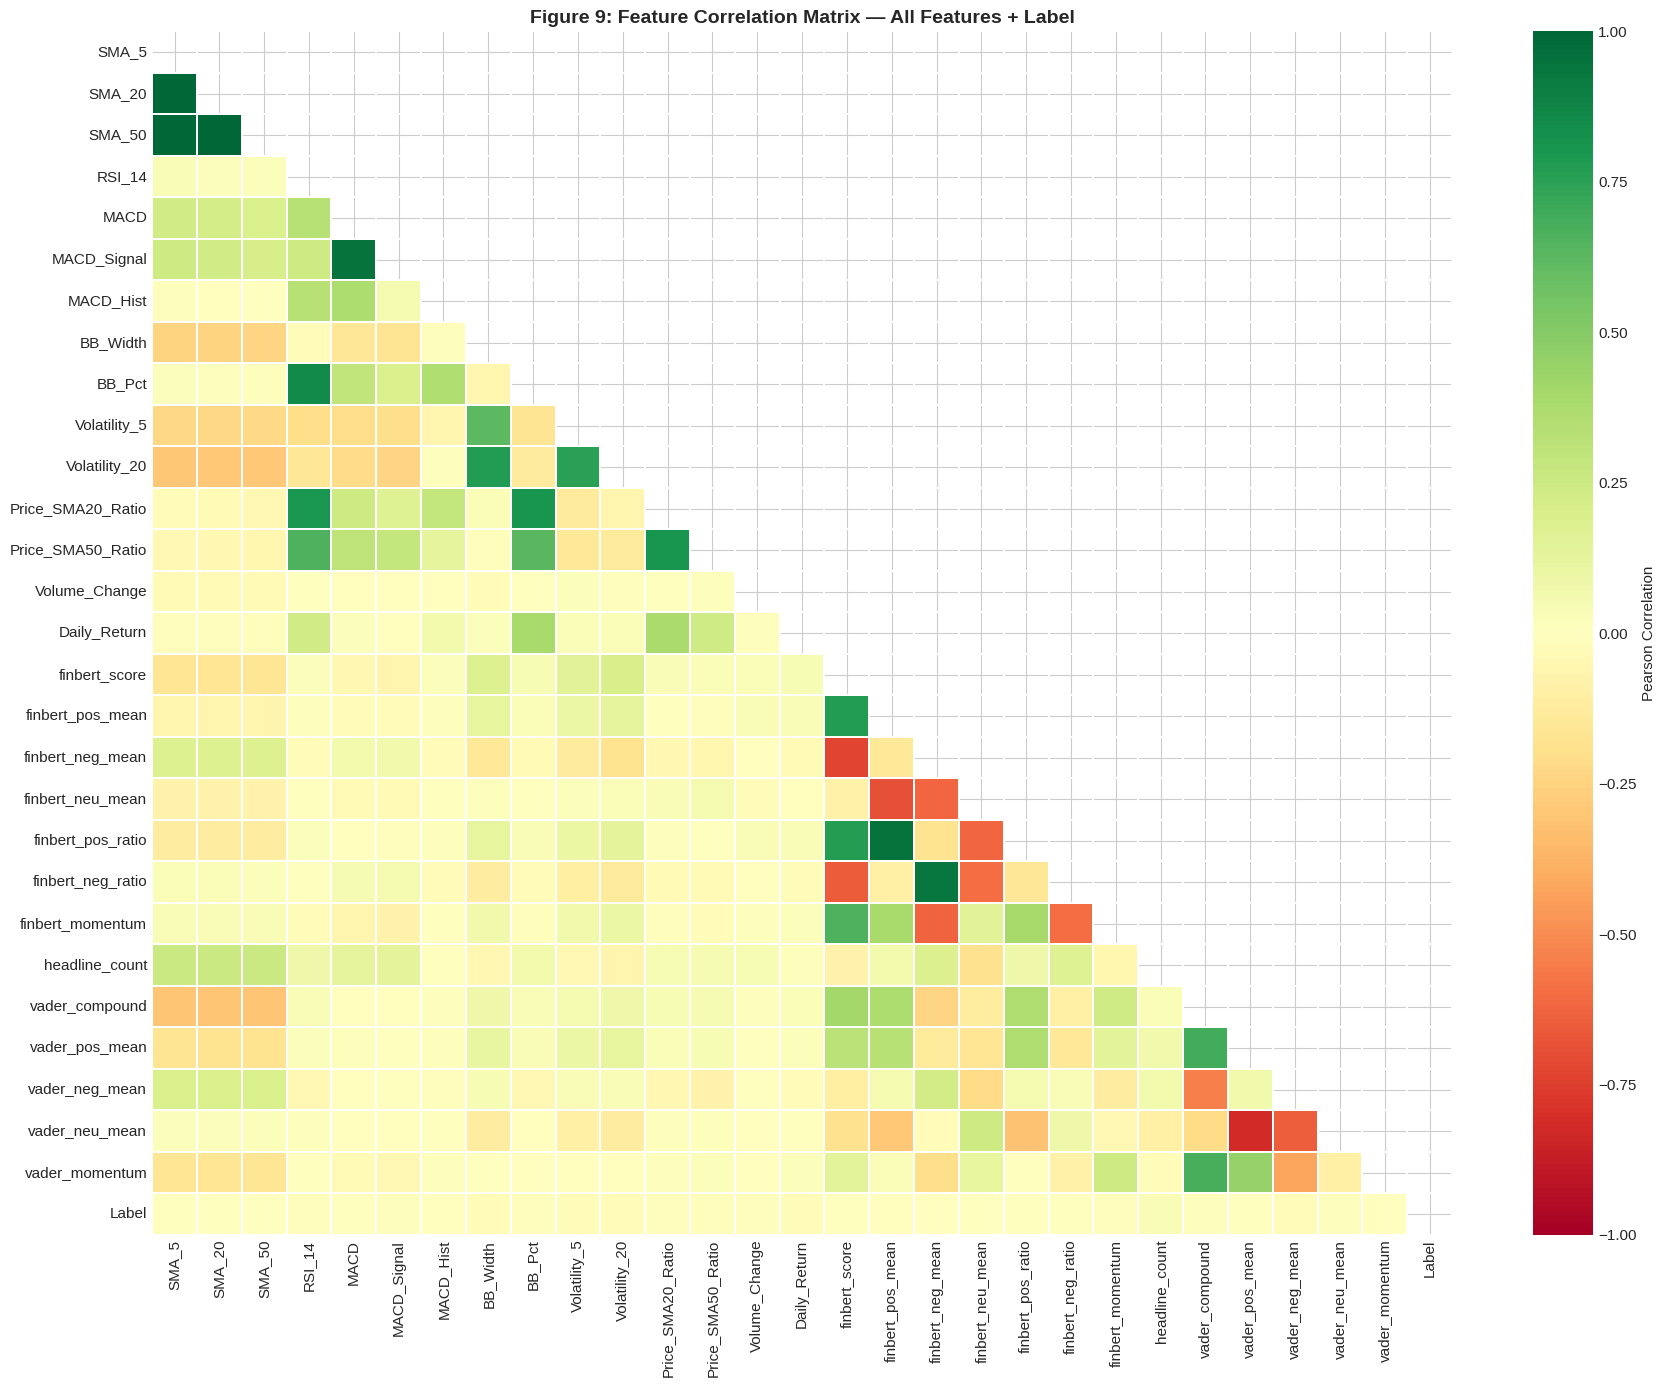

Saved: fig09_feature_correlation.png

Top 10 features correlated with Label:
headline_count       0.033463
Daily_Return         0.029781
Volatility_5         0.024371
vader_neg_mean       0.020644
BB_Width             0.019042
Volatility_20        0.016000
Volume_Change        0.013068
BB_Pct               0.011688
Price_SMA20_Ratio    0.010688
vader_compound       0.009460


In [10]:
all_features = TECH_FEATURES + ALL_SENT_FEATURES
corr_matrix  = merged[all_features + ['Label']].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title('Figure 9: Feature Correlation Matrix — All Features + Label',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig09_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig09_feature_correlation.png')

# Print top correlations with Label
label_corr = corr_matrix['Label'].drop('Label').abs().sort_values(ascending=False)
print('\nTop 10 features correlated with Label:')
print(label_corr.head(10).to_string())

## Cell 11 — Figure 10: Class balance across train/val/test splits

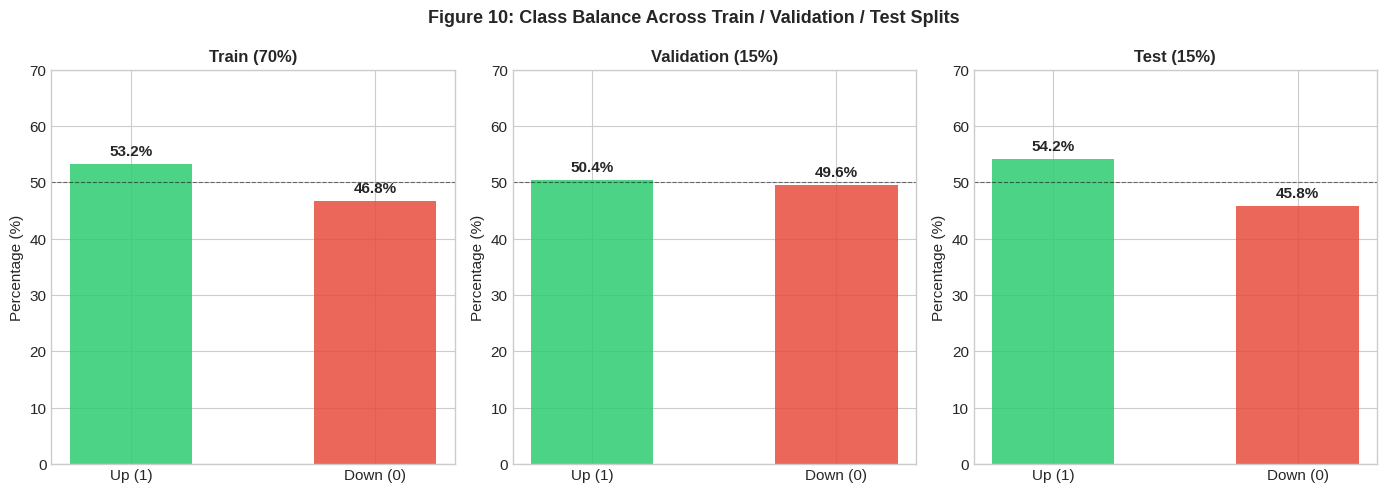

Saved: fig10_class_balance_splits.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
split_names  = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
split_frames = [train_df, val_df, test_df]
colors = ['#2ecc71', '#e74c3c']

for ax, name, df_ in zip(axes, split_names, split_frames):
    up_pct   = 100 * df_['Label'].mean()
    down_pct = 100 - up_pct
    ax.bar(['Up (1)', 'Down (0)'], [up_pct, down_pct],
           color=colors, alpha=0.85, width=0.5)
    ax.set_ylim(0, 70)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(0, up_pct + 1.5, f'{up_pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.text(1, down_pct + 1.5, f'{down_pct:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Figure 10: Class Balance Across Train / Validation / Test Splits',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig10_class_balance_splits.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig10_class_balance_splits.png')

## Cell 12 — Figure 11: Technical indicators sample (AAPL)

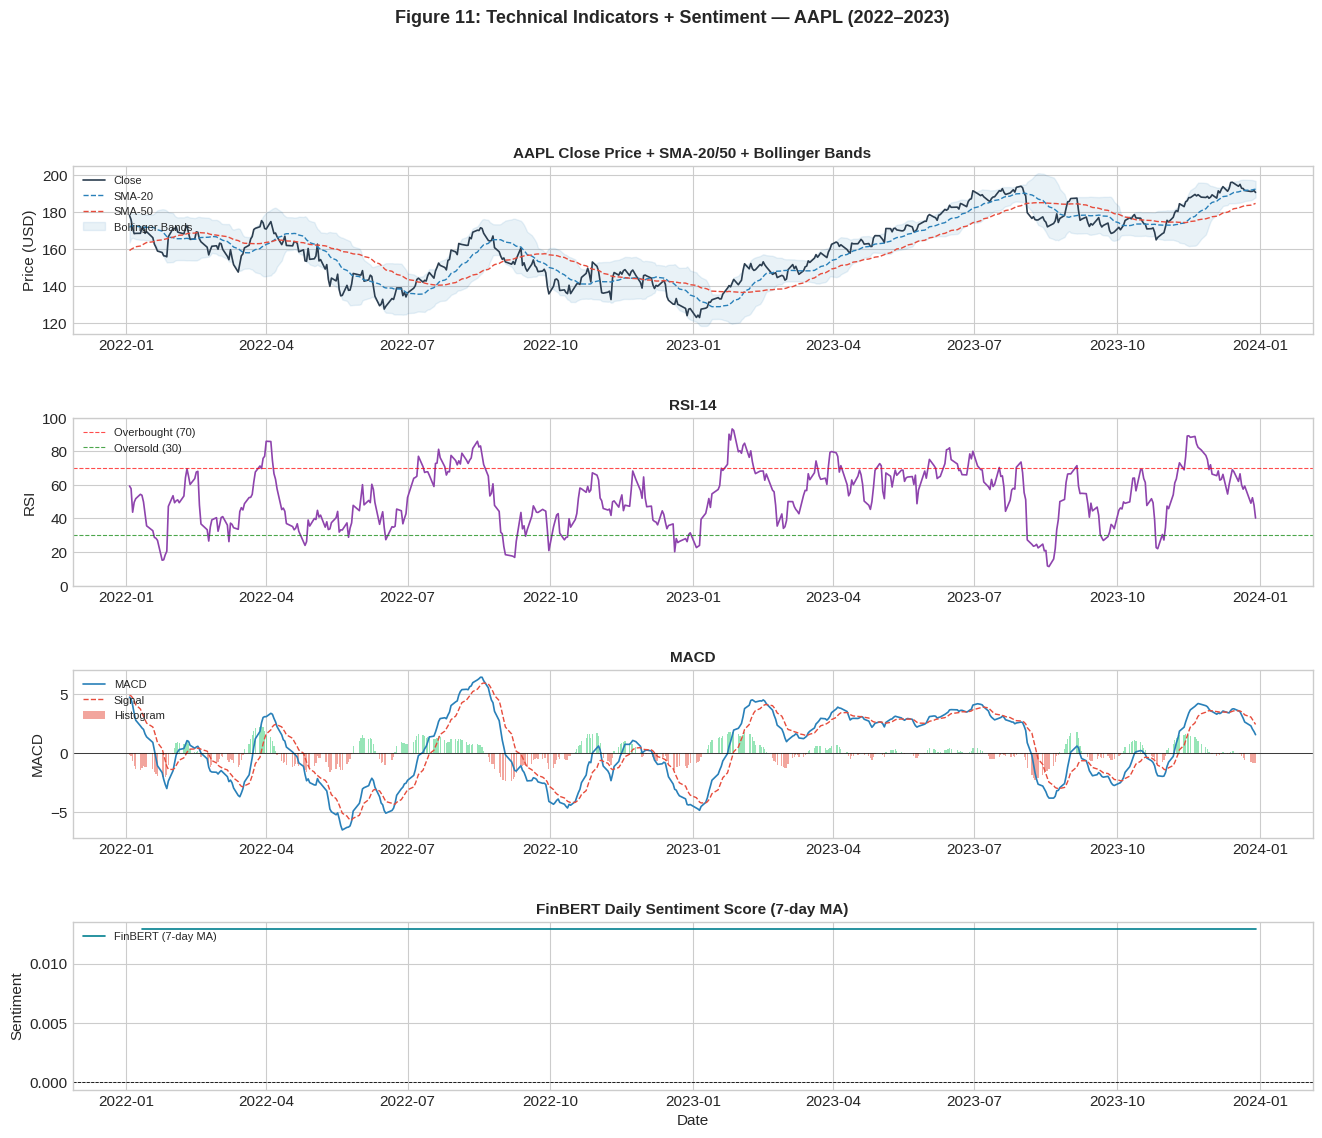

Saved: fig11_technical_indicators.png


In [12]:
aapl = merged[merged['Ticker'] == 'AAPL'].sort_values('Date').copy()
# Plot last 2 years for clarity
aapl_plot = aapl[aapl['Date'] >= '2022-01-01']

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(4, 1, hspace=0.5)

# Panel 1: Close + SMAs
ax1 = fig.add_subplot(gs[0])
ax1.plot(aapl_plot['Date'], aapl_plot['Close'],  color='#2c3e50', linewidth=1.2, label='Close')
ax1.plot(aapl_plot['Date'], aapl_plot['SMA_20'], color='#2980b9', linewidth=1.0, linestyle='--', label='SMA-20')
ax1.plot(aapl_plot['Date'], aapl_plot['SMA_50'], color='#e74c3c', linewidth=1.0, linestyle='--', label='SMA-50')
ax1.fill_between(aapl_plot['Date'], aapl_plot['BB_Lower'], aapl_plot['BB_Upper'],
                 alpha=0.1, color='#2980b9', label='Bollinger Bands')
ax1.set_title('AAPL Close Price + SMA-20/50 + Bollinger Bands', fontsize=11, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)
ax1.set_ylabel('Price (USD)')

# Panel 2: RSI
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(aapl_plot['Date'], aapl_plot['RSI_14'], color='#8e44ad', linewidth=1.2)
ax2.axhline(70, color='red',   linestyle='--', linewidth=0.8, alpha=0.7, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label='Oversold (30)')
ax2.set_ylim(0, 100)
ax2.set_title('RSI-14', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', fontsize=8)
ax2.set_ylabel('RSI')

# Panel 3: MACD
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(aapl_plot['Date'], aapl_plot['MACD'],        color='#2980b9', linewidth=1.2, label='MACD')
ax3.plot(aapl_plot['Date'], aapl_plot['MACD_Signal'], color='#e74c3c', linewidth=1.0, linestyle='--', label='Signal')
ax3.bar(aapl_plot['Date'], aapl_plot['MACD_Hist'],    color=aapl_plot['MACD_Hist'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c'), alpha=0.5, label='Histogram')
ax3.axhline(0, color='black', linewidth=0.5)
ax3.set_title('MACD', fontsize=11, fontweight='bold')
ax3.legend(loc='upper left', fontsize=8)
ax3.set_ylabel('MACD')

# Panel 4: FinBERT sentiment
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ax4.plot(aapl_plot['Date'], aapl_plot['finbert_score'].rolling(7).mean(),
         color='#028090', linewidth=1.2, label='FinBERT (7-day MA)')
ax4.axhline(0, color='black', linestyle='--', linewidth=0.6)
ax4.set_title('FinBERT Daily Sentiment Score (7-day MA)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Sentiment')
ax4.set_xlabel('Date')
ax4.legend(loc='upper left', fontsize=8)

plt.suptitle('Figure 11: Technical Indicators + Sentiment — AAPL (2022–2023)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(f'{OUTPUT_DIR}/fig11_technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig11_technical_indicators.png')

## Cell 13 — Coverage analysis: sentiment fill statistics

In [13]:
# How many rows have real (non-zero-filled) sentiment vs forward-filled vs zero-filled
print('=== Sentiment Coverage Analysis ===')

# Re-check original merge (before fill) by checking the raw sentiment join
orig_merge = price_tech.merge(
    sent_merge, left_on=['Date','Ticker'], right_on=['date','Ticker'], how='left'
).drop(columns=['date'], errors='ignore')

coverage_rows = []
for ticker in TICKERS:
    sub_orig = orig_merge[orig_merge['Ticker'] == ticker]
    sub_merged = merged[merged['Ticker'] == ticker]
    total = len(sub_orig)
    with_news = sub_orig['finbert_score'].notna().sum()
    coverage_rows.append({
        'Ticker': ticker,
        'Total Days': total,
        'Days with Real News': int(with_news),
        'Coverage %': f'{100*with_news/total:.1f}%',
        'Forward-filled Days': int(total - with_news)
    })

cov_df = pd.DataFrame(coverage_rows)
print(cov_df.to_string(index=False))
avg_cov = sum(int(r['Days with Real News']) for r in coverage_rows) / sum(r['Total Days'] for r in coverage_rows)
print(f'\nOverall average coverage: {100*avg_cov:.1f}%')
cov_df.to_csv(f'{OUTPUT_DIR}/coverage_analysis.csv', index=False)
print('Saved: coverage_analysis.csv')

=== Sentiment Coverage Analysis ===
Ticker  Total Days  Days with Real News Coverage %  Forward-filled Days
  AAPL        1258                  407      32.4%                  851
  MSFT        1258                  339      26.9%                  919
  AMZN        1258                  446      35.5%                  812
 GOOGL        1258                  364      28.9%                  894
  META        1258                  294      23.4%                  964
  TSLA        1258                  461      36.6%                  797
  NVDA        1258                  262      20.8%                  996
   JPM        1258                  359      28.5%                  899
  NFLX        1258                  335      26.6%                  923
 ^GSPC        1258                  464      36.9%                  794

Overall average coverage: 29.7%
Saved: coverage_analysis.csv


## Cell 14 — Save all outputs for NB4 and NB5

In [14]:
import pickle

# Save the full datasets dict (X/y arrays + scalers)
with open(f'{OUTPUT_DIR}/feature_datasets.pkl', 'wb') as f:
    pickle.dump(datasets, f)
print(f'Saved feature_datasets.pkl')

# Save the split dataframes (for reference and LSTM sequence building in NB5)
train_df.to_csv(f'{OUTPUT_DIR}/train_df.csv', index=False)
val_df.to_csv(  f'{OUTPUT_DIR}/val_df.csv',   index=False)
test_df.to_csv( f'{OUTPUT_DIR}/test_df.csv',  index=False)
merged.to_csv(  f'{OUTPUT_DIR}/merged_df.csv', index=False)
print(f'Saved train_df.csv ({len(train_df):,} rows)')
print(f'Saved val_df.csv   ({len(val_df):,} rows)')
print(f'Saved test_df.csv  ({len(test_df):,} rows)')
print(f'Saved merged_df.csv ({len(merged):,} rows)')

# Save feature config reference
import json
config_ref = {k: v['feature_cols'] for k, v in datasets.items()}
with open(f'{OUTPUT_DIR}/feature_configs.json', 'w') as f:
    json.dump(config_ref, f, indent=2)
print('Saved feature_configs.json')

# Save split summary
split_summary.to_csv(f'{OUTPUT_DIR}/split_summary.csv', index=False)
print('Saved split_summary.csv')

print('\n=== NB3 COMPLETE ===')
print('Files needed for NB4 (classical ML):')
print('  feature_datasets.pkl')
print('Files needed for NB5 (deep learning):')
print('  feature_datasets.pkl')
print('  train_df.csv / val_df.csv / test_df.csv')
print('  feature_configs.json')
print('Next: Run NB4 — Classical ML (CPU fine, GPU OFF to save quota)')

Saved feature_datasets.pkl
Saved train_df.csv (8,790 rows)
Saved val_df.csv   (1,880 rows)
Saved test_df.csv  (1,890 rows)
Saved merged_df.csv (12,560 rows)
Saved feature_configs.json
Saved split_summary.csv

=== NB3 COMPLETE ===
Files needed for NB4 (classical ML):
  feature_datasets.pkl
Files needed for NB5 (deep learning):
  feature_datasets.pkl
  train_df.csv / val_df.csv / test_df.csv
  feature_configs.json
Next: Run NB4 — Classical ML (CPU fine, GPU OFF to save quota)


---
## Summary
- **Technical indicators computed**: SMA-5/20/50, RSI-14, MACD/Signal/Hist, BB-Width/Pct, Volatility-5/20, Price-SMA ratios, Volume Change, Daily Return (15 features)
- **Sentiment features**: 8 FinBERT + 5 VADER = 13 features
- **4 ablation configs**: price_only (15), price_vader (20), price_finbert (23), price_both (28)
- **Split**: 70% train / 15% val / 15% test — chronological, no data leakage
- **Scaling**: StandardScaler fitted on training set only
- **Figures saved**: fig09 (correlation heatmap), fig10 (class balance splits), fig11 (technical indicators)